# Analyze Intrinsic Metrics

In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("../../scripts/")
from analysis.model_info import MODEL_INFORMATION
%load_ext autoreload
%autoreload 2

In [2]:
df = pd.read_json(
    "data/compiled_intrinsic_metrics_ar-cs-de.jsonl",
    orient="records",
    lines=True,
)

In [ ]:
df

In [4]:
import numpy as np
from sklearn.preprocessing import StandardScaler


def calculate_quality_score(df):
    """Calculate an aggregate quality score from intrinsic metrics using z-score normalization.

    Each metric is standardized (mean=0, std=1) and then averaged. This approach:
    - Handles extreme outliers automatically
    - Gives equal weight to each metric in terms of variance
    - Incorporates all 4 metrics: prompts_distinct_ri, responses_distinct_ri,
      rubric_score, and perplexity (log-transformed and inverted)

    df (pd.DataFrame): DataFrame with columns: prompts_distinct_ri,
        responses_distinct_ri, rubric_score, perplexity

    RETURNS (pd.Series): Quality scores for each row (higher is better)
    """
    data = np.column_stack(
        [
            df["prompts_distinct_ri"],
            df["responses_distinct_ri"],
            df["rubric_score"],
            -np.log1p(df["perplexity"]),
        ]
    )

    # Standardize and average
    scaler = StandardScaler()
    normalized = scaler.fit_transform(data)
    quality_score = normalized.mean(axis=1)

    return quality_score

In [5]:
# Calculate quality score
df["quality_score"] = calculate_quality_score(df)

# Show top models by quality score
df[
    [
        "language",
        "model",
        "quality_score",
        "rubric_score",
        "responses_distinct_ri",
        "prompts_distinct_ri",
        "perplexity",
    ]
].sort_values("quality_score", ascending=False)

,language,model,quality_score,rubric_score,responses_distinct_ri,prompts_distinct_ri,perplexity
22,de,google/gemma-3-12b-it,0.978179,4.2028,0.898606,0.751085,4.060759
24,de,google/gemma-3-4b-it,0.882591,4.1030,0.897925,0.744396,3.963183
23,de,google/gemma-3-27b-it,0.827283,4.2601,0.897766,0.730997,3.960716
21,de,cohere-command-a,0.738747,4.2353,0.889303,0.729790,3.586949
25,de,gpt-4o-mini-2024-07-18,0.597294,3.8100,0.888769,0.731964,3.650469
20,de,CohereLabs/aya-expanse-32b,0.574391,4.1400,0.901674,0.700103,3.441957
27,de,ibm-granite/granite-4.0-micro,0.523330,3.7037,0.892299,0.725769,4.591788
3,ar,google/gemma-3-27b-it,0.515359,3.9315,0.889779,0.717244,4.403990
0,ar,CohereLabs/aya-expanse-32b,0.310859,3.9640,0.888060,0.692789,4.337098
13,cs,google/gemma-3-27b-it,0.283105,4.3416,0.884775,0.675320,3.772706


NameError: name 'plot_theme' is not defined

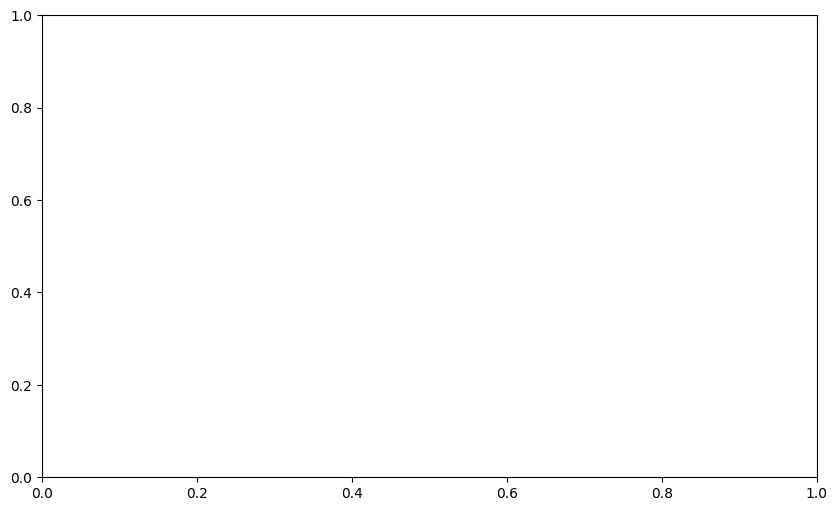

In [ ]:
# Merge model size information
model_info_df = pd.DataFrame([m.model_dump() for m in MODEL_INFORMATION])
df_with_size = df.merge(
    model_info_df[["name", "parameter_size", "model_family"]],
    left_on="model",
    right_on="name",
    how="left",
)

# Filter out models with unknown size
df_plot = df_with_size[df_with_size["parameter_size"] != "Unknown"].copy()
df_plot["parameter_size"] = df_plot["parameter_size"].astype(float)

# Create scatter plot: model size vs quality score
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each model family with different colors
families = df_plot["model_family"].unique()
family_colors = {
    "Aya": plot_theme.COLORS["warm_blue"],
    "Command": plot_theme.COLORS["warm_crest"],
    "Gemma": plot_theme.COLORS["heritage"],
    "GPT-4o": plot_theme.COLORS["cherry"],
    "Granite": plot_theme.COLORS["slate"],
    "Llama": plot_theme.COLORS["purple"],
}

for family in families:
    family_data = df_plot[df_plot["model_family"] == family]
    ax.scatter(
        family_data["parameter_size"],
        family_data["quality_score"],
        label=family,
        color=family_colors.get(family, plot_theme.COLORS["blue"]),
        s=100,
        alpha=0.7,
        edgecolors="black",
        linewidth=1.5,
    )

ax.set_xlabel("Model Size (Billion Parameters)")
ax.set_xscale("log")
ax.set_ylabel("Quality Score")
ax.set_title("Does Model Size Predict Intrinsic Data Quality?")
ax.legend(frameon=True, loc="best")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
from scripts.analysis import plot_theme

# Configure plot theme with IBM Plex Sans option
use_ibm_plex = True  # Set to False to use Times

if use_ibm_plex:
    plot_params = {
        **plot_theme.PLOT_PARAMS,
        "font.family": "sans-serif",
        "font.sans-serif": ["IBM Plex Sans"],
        "text.usetex": False,  # IBM Plex Sans doesn't work well with LaTeX
    }
else:
    plot_params = plot_theme.PLOT_PARAMS.copy()

plt.rcParams.update(plot_params)